# Cross-Dictionary Replication of the SAE Auditability Spine (65k Gemma-Scope SAE)

This demo reproduces the **headline verdict tables** of experiment M2 *without any GPU / model run*.

The full `method.py` (2365 lines) loads `google/gemma-2-2b` + two Gemma-Scope SAE dictionaries, encodes
text corpora, re-derives anchors/absorbers, runs surgical activation edits, and saves everything to
`method_out.json`. **All of that is the expensive GPU half.** The *analysis* half — turning the saved
per-concept measurements into the four **auditability-spine** verdicts — is pure NumPy / statsmodels and is
exactly what this notebook runs (mirroring the artifact's own `repatch_verdicts.py`).

We load a curated slice of the saved output and re-derive, for each SAE dictionary, the four spine pieces:

| piece | question | 16k reference (iter-4) |
|---|---|---|
| **(A) homograph recall-holes** | does the parent's `recall_hole > 0.5` *and* `firing_jaccard < 0.1` reappear? | Georgia 0.77 / 0.012 |
| **(B) KG-repair FDR** | how many K-track repairs survive Benjamini-Hochberg FDR ≤ 0.05? | spelling 14 / tax 6 / numeric 10 |
| **(C) surgical edit** | is a single re-derived absorber a confirmed surgical edit (high selectivity)? | Georgia 1722× |
| **(D) router transfer** | do the *frozen* 16k thresholds still separate absorption vs co-firing? | balanced-acc 1.0 |

**Headline reproduced here:** the spine **fully replicates** on the 4× wider 65k layer-12 SAE (holes
reappear, *more* repairs survive — the *wider-SAE-absorbs-more* signal — Georgia's surgical edit is even
sharper, router thresholds transfer at balanced-accuracy 1.0), and **partially** on the layer-9 16k SAE
(absorption is layer-dependent). Cross-dictionary verdict = **full**.

In [1]:
# --- Install dependencies (Colab-safe) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

# Every package used here (numpy, scipy, pandas, statsmodels, matplotlib) is pre-installed on Colab.
# On Colab: do NOTHING (pip-installing these corrupts Colab's compiled C-extensions).
# Locally: install them at Colab's exact versions so the local env mirrors Colab.
if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "pandas==2.2.2", "scipy==1.16.3",
         "matplotlib==3.10.0", "statsmodels==0.14.6")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (the subset of method.py's imports used by the analysis path, + plotting) ---
import os, sys, json
from collections import defaultdict
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# --- Data loading: GitHub raw URL with local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-5/experiment-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("loaded mini_demo_data.json")
print("dictionaries:", list(data["per_dictionary_concept_results"].keys()))
for dn, lst in data["per_dictionary_concept_results"].items():
    print(f"  [{dn}] concepts:", [r["concept"] for r in lst])
print("published cross-dictionary verdict:", data["saved"]["verdict"]["cross_dictionary_replicates"],
      "| per-dict:", data["saved"]["verdict"]["per_dictionary"])

loaded mini_demo_data.json
dictionaries: ['65k', 'l9_16k']
  [65k] concepts: ['taxonomic', 'numeric', 'first_letter_L', 'first_letter_O', 'first_letter_T', 'first_letter_I', 'first_letter_D', 'toxicity']
  [l9_16k] concepts: ['taxonomic']
published cross-dictionary verdict: full | per-dict: {'65k': 'full', 'l9_16k': 'partial'}


## Configuration

Tunable knobs at the top. Because the re-derivation is pure NumPy on the *saved* measurements, the full
original settings run in well under a second — so we keep them at their original `method.py` values and the
notebook reproduces the published numbers exactly. Scale `B_BOOT` down (e.g. 200) for an even faster run, or
set `DICTS_TO_PROCESS = ["65k"]` to do only the primary dictionary.

In [5]:
# --- Config (original method.py values; all fit comfortably in the runtime budget) ---
SEED = 1234                          # method.py SEED
B_BOOT = 10000                       # method.py B_BOOT (paired/mean bootstrap iterations); try 200 for speed
FDR_ALPHA = 0.05                     # method.py FDR_ALPHA (Benjamini-Hochberg level)
DICTS_TO_PROCESS = ["65k", "l9_16k"] # method.py --dicts 65k,l9_16k  (primary 65k + reduced layer-9 16k)

rng = np.random.default_rng(SEED)    # method.py: rng = np.random.default_rng(SEED)

## Constants copied verbatim from `method.py`

`REF_16K` is the iter-4 width-16k reference (what we compare the new dictionaries against) and `DICTS` is the
per-dictionary SAE config. Both are copied verbatim from the original script.

In [6]:
# --- verbatim from method.py: 16k reference results (iter-4) ---
REF_16K = {
    "gating_cosine": 0.9189, "gating_L0": 87.9, "gating_layer_idx": 13,
    "per_family_survive_FDR": {"spelling": 14, "homograph_taxonomic": 6, "numeric": 10},
    "n_repairs_tested": 69, "n_holes": 54, "n_survive_FDR": 30,
    "router_tau_h": 0.7774337479718767, "router_tau_j": 0.05,
    "router_recall_hole_balanced_acc": 1.0, "router_firing_jaccard_balanced_acc": 0.9167,
    "surgical_georgia": {"verdict": "SURGICAL_EDIT_CONFIRMED", "selectivity_ratio": 1722.46,
                         "kg_collateral": 2.876e-05, "dense_collateral": 0.04955, "firing_jaccard": 0.012,
                         "parent_recall_hole": 0.77},
    "surgical_jordan": {"selectivity_ratio": 2722.0, "kg_collateral": 0.0, "dense_collateral": 0.0721,
                        "firing_jaccard": 0.014, "parent_recall_hole": 0.68},
    "regime_router_map": {"absorption_mean_selectivity": 1452.47, "absorption_mean_firing_jaccard": 0.0141,
                          "co_firing_mean_selectivity": 2.377, "co_firing_mean_firing_jaccard": 0.8776},
    "member_labeling_agreement": 0.7303, "member_labeling_gap": 0.6344,
}

# --- verbatim from method.py: per-dictionary SAE config ---
DICTS = {
    "65k":     {"layer": 12, "width": "65k", "l0_target": 100, "expect_l0": 72,
                "hidden_search": (11, 12, 13, 14), "expect_hidden": 13, "expect_dsae": 65536,
                "reduced": False},
    "l9_16k":  {"layer": 9,  "width": "16k", "l0_target": 100, "expect_l0": None,
                "hidden_search": (8, 9, 10, 11), "expect_hidden": 10, "expect_dsae": 16384,
                "reduced": True},
    "l6_16k":  {"layer": 6,  "width": "16k", "l0_target": 100, "expect_l0": None,
                "hidden_search": (5, 6, 7, 8), "expect_hidden": 7, "expect_dsae": 16384,
                "reduced": True},
}

## Pure analysis functions copied verbatim from `method.py` — part 1: statistics

The paired/mean bootstrap, Benjamini-Hochberg FDR, firing-Jaccard, balanced accuracy and the 1-D router
threshold sweep. These are exactly the functions `method.py` uses; nothing is re-implemented.

In [7]:
# === verbatim from method.py ===
def paired_bootstrap_diff_items(diff_per_item, B=B_BOOT):
    """Paired bootstrap of mean(diff). Returns 95% CI + one-sided p (H0: mean<=0)."""
    d = np.asarray(diff_per_item, dtype=np.float64)
    n = len(d)
    if n == 0:
        return {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n": 0, "p_one_sided": 1.0}
    idx = rng.integers(0, n, size=(B, n))
    bs = d[idx].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    p_one = (1.0 + float((bs <= 0).sum())) / (B + 1.0)
    return {"diff": float(d.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
            "excl_0": bool(lo > 0 or hi < 0), "n": int(n), "p_one_sided": float(p_one)}


def bootstrap_mean_ci(values, B=B_BOOT):
    v = np.asarray(values, float); n = len(v)
    if n == 0:
        return {"mean": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "n": 0, "excl_0": False}
    idx = rng.integers(0, n, size=(B, n))
    bs = v[idx].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return {"mean": float(v.mean()), "ci_lo": float(lo), "ci_hi": float(hi), "n": int(n),
            "excl_0": bool(lo > 0 or hi < 0)}


def benjamini_hochberg(pvals, alpha=FDR_ALPHA):
    p = np.asarray(pvals, dtype=np.float64)
    n = len(p)
    if n == 0:
        return np.array([]), 0
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty(n)
    out[order] = q
    return out, int((out <= alpha).sum())


def firing_jaccard(fires_a, fires_b):
    a = np.asarray(fires_a).astype(bool); b = np.asarray(fires_b).astype(bool)
    inter = int((a & b).sum()); union = int((a | b).sum())
    return (inter / union) if union > 0 else 0.0


def balanced_accuracy(pred, truth):
    pred = np.asarray(pred); truth = np.asarray(truth)
    accs = []
    for cls in ["absorption", "co_firing"]:
        m = truth == cls
        if m.sum() == 0:
            continue
        accs.append((pred[m] == cls).mean())
    return float(np.mean(accs)) if accs else float("nan")


def derive_1d(concepts, key, lt):
    vals = np.array([c[key] for c in concepts], float)
    truth = np.array([c["ground_truth_regime"] for c in concepts])
    if len(vals) == 0 or not np.isfinite(vals).any():
        return float("nan"), float("nan"), []
    grid = np.linspace(float(np.nanmin(vals)), float(np.nanmax(vals)), 41)
    sweep = []
    for tau in grid:
        pred = np.where(vals < tau if lt else vals > tau, "absorption", "co_firing")
        sweep.append({"tau": float(tau), "balanced_acc": balanced_accuracy(pred, truth)})
    best = max(sweep, key=lambda r: r["balanced_acc"])
    return best["tau"], best["balanced_acc"], sweep


def apply_frozen_threshold(concepts, key, tau, lt):
    vals = np.array([c[key] for c in concepts], float)
    truth = np.array([c["ground_truth_regime"] for c in concepts])
    pred = np.where(vals < tau if lt else vals > tau, "absorption", "co_firing")
    return balanced_accuracy(pred, truth), pred.tolist()

## Pure analysis functions copied verbatim from `method.py` — part 2: multiplicity, router, replication table

`apply_multiplicity` runs BH-FDR across every measured repair of a dictionary (cross-checked against
statsmodels); `router_transfer` applies the frozen 16k thresholds and re-derives optimal ones;
`build_replication_table` / `replication_dataset_rows` assemble the four per-piece verdicts and the
output dataset rows. All verbatim.

In [8]:
# === verbatim from method.py ===
def family_of(concept):
    if concept == "taxonomic":
        return "homograph_taxonomic"
    if concept == "numeric":
        return "numeric"
    return "spelling"


def apply_multiplicity(concept_results):
    """BH FDR across ALL measured repair variants from all concepts of ONE dictionary. M3 honest counting:
    de-duplicate kg_diagnostic variants that name the SAME latent as kg_ktrack."""
    rows = []
    for res in concept_results:
        concept = res["concept"]
        rep = res.get("repair", {})
        for X, e in rep.get("per_subcontext", {}).items():
            if e.get("status") != "measured":
                continue
            for vname, v in e.get("variants", {}).items():
                rows.append((concept, X, vname, v))
    pvals = [v["p_value_one_sided"] for (_, _, _, v) in rows]
    q, n_sig = benjamini_hochberg(pvals, FDR_ALPHA)
    sm_ok = None
    try:
        from statsmodels.stats.multitest import multipletests
        if pvals:
            rej, q_sm, _, _ = multipletests(pvals, alpha=FDR_ALPHA, method="fdr_bh")
            sm_ok = bool(np.allclose(q_sm, q, atol=1e-9))
    except Exception:  # noqa: BLE001
        sm_ok = None
    fam = {"spelling": 0, "homograph_taxonomic": 0, "numeric": 0}
    fam_sig = {"spelling": 0, "homograph_taxonomic": 0, "numeric": 0}
    distinct = defaultdict(set)            # family -> set of (X, latent) distinct holes that survive
    n_meas_succ = 0
    for i, (concept, X, vname, v) in enumerate(rows):
        v["bh_q"] = float(q[i]); v["survives_FDR"] = bool(q[i] <= FDR_ALPHA)
        f = family_of(concept.replace("first_letter_", "FL_") if concept.startswith("first_letter") else concept)
        fam[f] += 1
        if v["survives_FDR"]:
            fam_sig[f] += 1
            distinct[f].add((concept, str(X), int(v["absorber_latent"])))
        if v["measured_success"]:
            n_meas_succ += 1
    n_hole = sum(1 for res in concept_results for X, e in res.get("repair", {}).get("per_subcontext", {}).items()
                 if e.get("status") == "measured" and e.get("is_hole"))
    distinct_count = {k: len(v) for k, v in distinct.items()}
    return {"method": "Benjamini-Hochberg FDR", "alpha": FDR_ALPHA, "n_repairs_tested": len(rows), "n_holes": n_hole,
            "n_measured_success_uncorrected": n_meas_succ, "n_survive_FDR": n_sig,
            "statsmodels_crosscheck_matches": sm_ok, "per_family_tested": fam, "per_family_survive_FDR": fam_sig,
            "distinct_hole_count_survive_FDR": distinct_count,
            "distinct_total_survive_FDR": int(sum(distinct_count.values()))}


def router_transfer(concept_results, tox_result):
    """Build the per-concept router set (absorption concepts + toxicity co-firing sub-attributes), apply the
    FROZEN 16k thresholds (recall-hole lead tau_h, firing-Jaccard corroborating tau_j) WITHOUT refit, and
    re-derive 65k-optimal thresholds. transfer = frozen thresholds still give high balanced-accuracy."""
    concepts = []
    for res in concept_results:
        agg = res.get("router_agg", {})
        if not np.isfinite(agg.get("recall_hole_max", float("nan"))):
            continue
        concepts.append({"concept": res["concept"], "ground_truth_regime": "absorption",
                         "recall_hole_max": agg["recall_hole_max"], "firing_jaccard_median": agg["firing_jaccard_median"]})
    if tox_result is not None:
        for r in tox_result.get("router_per_subcontext", []):
            if np.isfinite(r.get("recall_hole", float("nan"))):
                concepts.append({"concept": f"toxicity:{r['sub_context']}", "ground_truth_regime": "co_firing",
                                 "recall_hole_max": r["recall_hole"], "firing_jaccard_median": r["firing_jaccard"]})
    if len(concepts) < 3 or len({c["ground_truth_regime"] for c in concepts}) < 2:
        return {"status": "insufficient_concepts", "n_concepts": len(concepts), "concepts": concepts}
    frozen_h_bacc, frozen_h_pred = apply_frozen_threshold(concepts, "recall_hole_max", REF_16K["router_tau_h"], lt=False)
    frozen_j_bacc, frozen_j_pred = apply_frozen_threshold(concepts, "firing_jaccard_median", REF_16K["router_tau_j"], lt=True)
    tau_h_65, bacc_h_65, sweep_h = derive_1d(concepts, "recall_hole_max", lt=False)
    tau_j_65, bacc_j_65, sweep_j = derive_1d(concepts, "firing_jaccard_median", lt=True)
    return {"status": "derived", "n_concepts": len(concepts), "concepts": concepts,
            "lead_signal": "recall_hole_alone (firing-Jaccard corroborating, per M6)",
            "frozen_16k_thresholds": {"tau_h": REF_16K["router_tau_h"], "tau_j": REF_16K["router_tau_j"]},
            "frozen_16k_recall_hole_balanced_acc": frozen_h_bacc,
            "frozen_16k_firing_jaccard_balanced_acc": frozen_j_bacc,
            "rederived_65k_tau_h": tau_h_65, "rederived_65k_recall_hole_balanced_acc": bacc_h_65,
            "rederived_65k_tau_j": tau_j_65, "rederived_65k_firing_jaccard_balanced_acc": bacc_j_65,
            "balanced_acc_recall_hole_alone": frozen_h_bacc, "balanced_acc_combined": max(frozen_h_bacc, frozen_j_bacc),
            "tau_h": tau_h_65, "tau_j": tau_j_65,
            "transfers": bool(frozen_h_bacc >= 0.8), "tau_h_close_to_16k": bool(abs(tau_h_65 - REF_16K["router_tau_h"]) < 0.2)}


def _find_sub(router_ps, name):
    for r in router_ps:
        if str(r["sub_context"]) == name:
            return r
    return None


def build_replication_table(dict_name, cfg, sae, gating, concept_results, tox_result, multiplicity, router_xfer):
    tax = next((r for r in concept_results if r["concept"] == "taxonomic"), None)
    # ---- piece A: homograph recall-holes ----
    homo = {}
    geo = jor = None
    if tax is not None:
        for r in tax.get("router_per_subcontext", []):
            if r["sub_context"] in ("Georgia", "Jordan", "United States", "Turkey", "Chile", "Iran"):
                homo[r["sub_context"]] = {"recall_hole": r["recall_hole"], "firing_jaccard": r["firing_jaccard"],
                                          "n_pos": r["n_pos"], "detector_latent": r["detector_latent"]}
        geo = _find_sub(tax.get("router_per_subcontext", []), "Georgia")
        jor = _find_sub(tax.get("router_per_subcontext", []), "Jordan")
    geo_hole_ok = bool(geo and geo["recall_hole"] > 0.5 and geo["firing_jaccard"] < 0.1)
    jor_hole_ok = bool(jor and jor["recall_hole"] > 0.5 and jor["firing_jaccard"] < 0.1)
    holes_replicate = geo_hole_ok or jor_hole_ok
    piece_A = "REPLICATES" if (geo_hole_ok and jor_hole_ok) else ("PARTIAL" if holes_replicate else "DICTIONARY_DEPENDENT")

    reduced = cfg.get("reduced", False)
    # ---- piece B: repair FDR ----
    fam_sig = multiplicity.get("per_family_survive_FDR", {})
    deltas = {f: fam_sig.get(f, 0) - REF_16K["per_family_survive_FDR"].get(f, 0)
              for f in REF_16K["per_family_survive_FDR"]}
    tax_repairs_survive = fam_sig.get("homograph_taxonomic", 0) >= 1
    any_family_survives = any(v >= 1 for v in fam_sig.values())
    if reduced:
        # reduced run tests ONLY the taxonomic family -> judge on homograph-taxonomic alone
        piece_B = "REPLICATES" if tax_repairs_survive else ("PARTIAL" if any_family_survives else "DICTIONARY_DEPENDENT")
    else:
        piece_B = ("REPLICATES" if (tax_repairs_survive and sum(fam_sig.values()) >= 3) else
                   ("PARTIAL" if any_family_survives else "DICTIONARY_DEPENDENT"))

    # ---- piece C: surgical ----
    surg_cases = []
    for res in concept_results:
        surg_cases.extend(res.get("surgical_cases", []))
    if tox_result is not None:
        surg_cases.extend(tox_result.get("surgical_cases", []))   # include the co-firing negative pole
    absn = [c for c in surg_cases if c.get("regime") == "absorption" and "matched" in c]
    confirmed = [c for c in absn if c.get("verdict") == "SURGICAL_EDIT_CONFIRMED"]
    best_surg = max(absn, key=lambda c: c.get("headline_selectivity_ratio", 0), default=None)
    surg_clean = [c for c in absn if c.get("headline_selectivity_ratio", 0) >= 20
                  and c.get("selectivity_CIs", {}).get("dense_minus_kg_collateral", {}).get("excl_0")]
    piece_C = ("REPLICATES" if confirmed else ("PARTIAL" if surg_clean else "DICTIONARY_DEPENDENT"))
    surgical_summary = []
    for c in surg_cases:
        ci = c.get("selectivity_CIs", {})
        surgical_summary.append({
            "family": c.get("family"), "subcontext": c.get("target_subcontext"), "absorber": c.get("absorber_latent"),
            "verdict": c.get("verdict"), "selectivity_ratio": c.get("headline_selectivity_ratio"),
            "kg_collateral": ci.get("KG-ABL_collateral", {}).get("mean"),
            "dense_collateral": ci.get("DENSE-ABL_collateral", {}).get("mean"),
            "dense_minus_kg_excl0": ci.get("dense_minus_kg_collateral", {}).get("excl_0"),
            "kg_offtarget_footprint": c.get("matched", {}).get("KG-ABL", {}).get("token_footprint_offtarget"),
            "firing_jaccard": c.get("firing_jaccard_with_parent"), "parent_recall_hole": c.get("parent_recall_hole"),
            "regime": c.get("regime")})

    # ---- piece D: router ----
    router_transfers = bool(router_xfer.get("transfers", False))
    if router_xfer.get("status") != "derived":
        # reduced run / too few concepts to test the multi-concept router threshold transfer
        piece_D = "NOT_RUN_REDUCED"
    else:
        piece_D = ("REPLICATES" if router_xfer.get("frozen_16k_recall_hole_balanced_acc", 0) >= 0.8 else
                   ("PARTIAL" if router_xfer.get("rederived_65k_recall_hole_balanced_acc", 0) >= 0.8 else "DICTIONARY_DEPENDENT"))

    # ---- regime split ----
    cofn = [c for c in surg_cases if c.get("regime") == "co-firing" and "matched" in c]
    def _mean(xs):
        xs = [x for x in xs if x is not None]
        return float(np.mean(xs)) if xs else None
    regime_split = {
        "absorption_mean_selectivity": _mean([c.get("headline_selectivity_ratio") for c in absn]),
        "absorption_mean_firing_jaccard": _mean([c.get("firing_jaccard_with_parent") for c in absn]),
        "co_firing_mean_selectivity": _mean([c.get("headline_selectivity_ratio") for c in cofn]),
        "co_firing_mean_firing_jaccard": _mean([c.get("firing_jaccard_with_parent") for c in cofn]),
        "n_absorption": len(absn), "n_co_firing": len(cofn)}

    pieces = {"homograph_holes": piece_A, "repair_fdr": piece_B, "surgical": piece_C, "router": piece_D}
    # overall verdict over only the pieces actually RUN (a reduced run excludes NOT_RUN_REDUCED pieces)
    vlist = [v for v in pieces.values() if v != "NOT_RUN_REDUCED"]
    if vlist and all(v == "REPLICATES" for v in vlist):
        overall = "full"
    elif vlist and all(v == "DICTIONARY_DEPENDENT" for v in vlist):
        overall = "dictionary_dependent"
    else:
        overall = "partial"

    return {
        "dictionary": dict_name, "layer": cfg["layer"], "width": cfg["width"], "sae_id": sae.sae_id,
        "avg_l0": sae.avg_l0, "gating": gating, "reduced_run": cfg.get("reduced", False),
        "re_derived_anchors": {res["concept"]: {"anchor": res.get("anchor"),
                                                "firing_floor_validated": res.get("anchor_info", {}).get("firing_floor_validated"),
                                                "corpus_fire_rate": res.get("anchor_info", {}).get("corpus_fire_rate"),
                                                "spurious": res.get("spurious_anchor")}
                               for res in concept_results},
        "homograph_holes": {"per_country": homo, "Georgia": {"hole_ok": geo_hole_ok, **(geo or {})},
                            "Jordan": {"hole_ok": jor_hole_ok, **(jor or {})}, "verdict": piece_A},
        "repair_fdr": {"per_family_survivors": fam_sig, "deltas_vs_16k": deltas,
                       "n_repairs_tested": multiplicity.get("n_repairs_tested"),
                       "n_survive_FDR": multiplicity.get("n_survive_FDR"),
                       "distinct_hole_count": multiplicity.get("distinct_hole_count_survive_FDR"),
                       "distinct_total": multiplicity.get("distinct_total_survive_FDR"),
                       "statsmodels_crosscheck": multiplicity.get("statsmodels_crosscheck_matches"),
                       "ref_16k": REF_16K["per_family_survive_FDR"], "verdict": piece_B},
        "surgical": {"n_cases": len(surg_cases), "n_confirmed": len(confirmed),
                     "best_selectivity_ratio": best_surg.get("headline_selectivity_ratio") if best_surg else None,
                     "cases": surgical_summary, "ref_16k_georgia": REF_16K["surgical_georgia"], "verdict": piece_C},
        "router": {"frozen_16k_recall_hole_balanced_acc": router_xfer.get("frozen_16k_recall_hole_balanced_acc"),
                   "frozen_16k_firing_jaccard_balanced_acc": router_xfer.get("frozen_16k_firing_jaccard_balanced_acc"),
                   "rederived_65k_tau_h": router_xfer.get("rederived_65k_tau_h"),
                   "rederived_65k_recall_hole_balanced_acc": router_xfer.get("rederived_65k_recall_hole_balanced_acc"),
                   "tau_h": router_xfer.get("tau_h"), "tau_j": router_xfer.get("tau_j"),
                   "balanced_acc_recall_hole_alone": router_xfer.get("balanced_acc_recall_hole_alone"),
                   "balanced_acc_combined": router_xfer.get("balanced_acc_combined"),
                   "transfers": router_transfers, "ref_16k_tau_h": REF_16K["router_tau_h"], "verdict": piece_D},
        "regime_split": regime_split, "per_piece_verdicts": pieces, "overall_verdict": overall}


def replication_dataset_rows(table):
    """One exp_gen_sol_out example per (dictionary x piece x sub_context). input=descriptor, output=verdict."""
    dn = table["dictionary"]; ex = []
    # piece A homograph holes
    for country, d in table["homograph_holes"]["per_country"].items():
        rh = d.get("recall_hole"); jac = d.get("firing_jaccard")
        verdict = "HOLE_REPLICATES" if (rh is not None and rh > 0.5 and jac is not None and jac < 0.1) else "NO_HOLE"
        ex.append({"input": f"[{dn}|homograph_hole|{country}] does the parent recall-hole + low firing-Jaccard reappear on this dictionary?",
                   "output": verdict, "predict_hole_recall": (f"{float(rh):.4f}" if rh is not None else "NA"),
                   "metadata_dictionary": dn, "metadata_layer": table["layer"], "metadata_width": table["width"],
                   "metadata_piece": "homograph_holes", "metadata_subcontext": country,
                   "metadata_recall_hole": rh, "metadata_firing_jaccard": jac})
    # piece B repair fdr (per concept x X x variant from the concept results is huge; summarize per family)
    for fam, n in table["repair_fdr"]["per_family_survivors"].items():
        ex.append({"input": f"[{dn}|repair_fdr|{fam}] how many KG-repairs survive BH FDR<=0.05 vs 16k?",
                   "output": str(int(n)), "predict_delta_vs_16k": str(table["repair_fdr"]["deltas_vs_16k"].get(fam)),
                   "metadata_dictionary": dn, "metadata_piece": "repair_fdr", "metadata_subcontext": fam,
                   "metadata_survivors": int(n), "metadata_ref_16k": REF_16K["per_family_survive_FDR"].get(fam),
                   "metadata_delta_vs_16k": table["repair_fdr"]["deltas_vs_16k"].get(fam)})
    # piece C surgical (per case)
    for c in table["surgical"]["cases"]:
        ex.append({"input": f"[{dn}|surgical|{c['family']}/{c['subcontext']}] KG-ABL single re-derived absorber {c['absorber']}; surgical edit verdict?",
                   "output": c["verdict"], "predict_selectivity_ratio": (f"{c['selectivity_ratio']:.2f}" if c.get("selectivity_ratio") is not None else "NA"),
                   "metadata_dictionary": dn, "metadata_piece": "surgical", "metadata_subcontext": str(c["subcontext"]),
                   "metadata_family": c["family"], "metadata_absorber_latent": c["absorber"], "metadata_regime": c["regime"],
                   "metadata_selectivity_ratio": c["selectivity_ratio"], "metadata_kg_collateral": c["kg_collateral"],
                   "metadata_dense_collateral": c["dense_collateral"], "metadata_dense_minus_kg_excl0": c["dense_minus_kg_excl0"],
                   "metadata_firing_jaccard": c["firing_jaccard"], "metadata_parent_recall_hole": c["parent_recall_hole"]})
    # piece D router
    ex.append({"input": f"[{dn}|router] do FROZEN 16k thresholds (recall-hole lead) still classify absorption vs co-firing?",
               "output": "TRANSFERS" if table["router"]["transfers"] else "DICTIONARY_SPECIFIC",
               "predict_balanced_acc": (f"{table['router']['frozen_16k_recall_hole_balanced_acc']:.4f}"
                                        if table["router"].get("frozen_16k_recall_hole_balanced_acc") is not None else "NA"),
               "metadata_dictionary": dn, "metadata_piece": "router", "metadata_subcontext": "ALL",
               "metadata_frozen_16k_balanced_acc": table["router"]["frozen_16k_recall_hole_balanced_acc"],
               "metadata_rederived_65k_balanced_acc": table["router"]["rederived_65k_recall_hole_balanced_acc"],
               "metadata_tau_h": table["router"]["tau_h"]})
    # overall
    ex.append({"input": f"[{dn}|OVERALL] cross-dictionary replication verdict for the auditability spine",
               "output": table["overall_verdict"].upper(), "predict_overall_verdict": table["overall_verdict"].upper(),
               "metadata_dictionary": dn, "metadata_piece": "overall", "metadata_subcontext": "ALL",
               "metadata_per_piece": json.dumps(table["per_piece_verdicts"])})
    return ex

## Piece (A) — homograph recall-holes

For each homograph country, the SAE country **parent** latent should fire on the country sense but *not* on
the homograph (Georgia the US state, the Jordan river, …). A **hole** = the parent's `recall_hole > 0.5`
together with a low positive-only `firing_jaccard < 0.1` between the parent and a content detector. We also
bootstrap (`bootstrap_mean_ci`, using `B_BOOT`) the mean recall-hole across *all* taxonomic sub-contexts.

In [9]:
HOMOGRAPH_COUNTRIES = ["Georgia", "Jordan", "United States"]
piece_a = {}
for dict_name in DICTS_TO_PROCESS:
    compact = data["per_dictionary_concept_results"][dict_name]
    tax = next((r for r in compact if r["concept"] == "taxonomic"), None)
    rows = tax.get("router_per_subcontext", []) if tax else []
    by_country = {r["sub_context"]: r for r in rows if r["sub_context"] in HOMOGRAPH_COUNTRIES}
    print(f"\n=== [{dict_name}] homograph holes  (hole = recall_hole>0.5 AND firing_jaccard<0.1) ===")
    for c in HOMOGRAPH_COUNTRIES:
        r = by_country.get(c)
        if r is None:
            print(f"  {c:14s} (sub-context not present)"); continue
        is_hole = r["recall_hole"] > 0.5 and r["firing_jaccard"] < 0.1
        print(f"  {c:14s} recall_hole={r['recall_hole']:.4f}  firing_jaccard={r['firing_jaccard']:.4f}"
              f"  -> {'HOLE' if is_hole else 'no hole'}")
    ci = bootstrap_mean_ci([r["recall_hole"] for r in rows], B=B_BOOT)
    print(f"  mean recall-hole over {ci['n']} taxonomic sub-contexts = {ci['mean']:.3f}"
          f"  95% CI [{ci['ci_lo']:.3f}, {ci['ci_hi']:.3f}]  (B_BOOT={B_BOOT})")
    piece_a[dict_name] = {"by_country": by_country, "bootstrap_mean_recall_hole": ci}


=== [65k] homograph holes  (hole = recall_hole>0.5 AND firing_jaccard<0.1) ===
  Georgia        recall_hole=0.8733  firing_jaccard=0.0038  -> HOLE
  Jordan         recall_hole=0.7460  firing_jaccard=0.0966  -> HOLE
  United States  recall_hole=1.0000  firing_jaccard=0.0264  -> HOLE
  mean recall-hole over 52 taxonomic sub-contexts = 0.061  95% CI [0.012, 0.124]  (B_BOOT=10000)

=== [l9_16k] homograph holes  (hole = recall_hole>0.5 AND firing_jaccard<0.1) ===
  Georgia        recall_hole=0.0033  firing_jaccard=0.0781  -> no hole
  Jordan         recall_hole=0.5363  firing_jaccard=0.0459  -> HOLE
  United States  recall_hole=0.0133  firing_jaccard=0.0600  -> no hole
  mean recall-hole over 52 taxonomic sub-contexts = 0.011  95% CI [0.000, 0.032]  (B_BOOT=10000)


## Piece (B) — KG-repair survivors under Benjamini-Hochberg FDR

The broad K-track names a covering absorber per eligible sub-context and tests recall recovery against a
random single-latent control (one-sided paired-bootstrap p-value, saved per variant). `apply_multiplicity`
applies BH-FDR ≤ 0.05 across **all** variants of a dictionary and counts survivors per family — and
cross-checks the q-values against statsmodels. The **deltas vs the 16k counts** are the predicted
*wider-SAE-absorbs-more* signal.

In [10]:
multiplicity_by_dict = {}
for dict_name in DICTS_TO_PROCESS:
    compact = data["per_dictionary_concept_results"][dict_name]
    concept_results = [r for r in compact if r.get("concept") != "toxicity"]
    mult = apply_multiplicity(concept_results)
    multiplicity_by_dict[dict_name] = mult
    fam = mult["per_family_survive_FDR"]
    deltas = {f: fam.get(f, 0) - REF_16K["per_family_survive_FDR"].get(f, 0)
              for f in REF_16K["per_family_survive_FDR"]}
    print(f"\n=== [{dict_name}] KG-repair BH-FDR survivors (alpha={FDR_ALPHA}) ===")
    print(f"  tested={mult['n_repairs_tested']}  survive_FDR={mult['n_survive_FDR']}"
          f"  statsmodels_crosscheck={mult['statsmodels_crosscheck_matches']}")
    print(f"  {'family':20s} {'this dict':>9s} {'16k ref':>8s} {'delta':>7s}")
    for f in ["spelling", "homograph_taxonomic", "numeric"]:
        print(f"  {f:20s} {fam.get(f,0):>9d} {REF_16K['per_family_survive_FDR'].get(f,0):>8d} {deltas[f]:>+7d}")


=== [65k] KG-repair BH-FDR survivors (alpha=0.05) ===
  tested=154  survive_FDR=55  statsmodels_crosscheck=True
  family               this dict  16k ref   delta
  spelling                    29       14     +15
  homograph_taxonomic         11        6      +5
  numeric                     15       10      +5

=== [l9_16k] KG-repair BH-FDR survivors (alpha=0.05) ===
  tested=84  survive_FDR=2  statsmodels_crosscheck=True
  family               this dict  16k ref   delta
  spelling                     0       14     -14
  homograph_taxonomic          2        6      -4
  numeric                      0       10     -10


## Piece (D) — router transfer

Build the per-concept router set (absorption concepts + the toxicity co-firing negative pole), apply the
**frozen** 16k thresholds without refit, and re-derive the 65k-optimal threshold. *Transfer* = the frozen
recall-hole threshold still gives balanced-accuracy ≥ 0.8. The reduced layer-9 run lacks co-firing concepts,
so its router piece is `NOT_RUN_REDUCED`.

In [11]:
router_by_dict = {}
for dict_name in DICTS_TO_PROCESS:
    compact = data["per_dictionary_concept_results"][dict_name]
    concept_results = [r for r in compact if r.get("concept") != "toxicity"]
    tox = next((r for r in compact if r.get("concept") == "toxicity"), None)
    rxfer = router_transfer(concept_results, tox)
    router_by_dict[dict_name] = rxfer
    print(f"\n=== [{dict_name}] router transfer ===")
    if rxfer["status"] != "derived":
        print(f"  status={rxfer['status']} (n_concepts={rxfer['n_concepts']}) -> NOT_RUN_REDUCED")
        continue
    print(f"  n_concepts={rxfer['n_concepts']}")
    print(f"  FROZEN 16k recall-hole threshold (tau_h={REF_16K['router_tau_h']:.4f}):"
          f"  balanced-acc = {rxfer['frozen_16k_recall_hole_balanced_acc']:.4f}")
    print(f"  re-derived this-dict tau_h={rxfer['rederived_65k_tau_h']:.4f}:"
          f"  balanced-acc = {rxfer['rederived_65k_recall_hole_balanced_acc']:.4f}")
    print(f"  transfers (frozen bal-acc >= 0.8): {rxfer['transfers']}")


=== [65k] router transfer ===
  n_concepts=11
  FROZEN 16k recall-hole threshold (tau_h=0.7774):  balanced-acc = 1.0000
  re-derived this-dict tau_h=0.0000:  balanced-acc = 1.0000
  transfers (frozen bal-acc >= 0.8): True

=== [l9_16k] router transfer ===
  status=insufficient_concepts (n_concepts=1) -> NOT_RUN_REDUCED


## Assemble the replication table + per-piece verdicts

`build_replication_table` folds pieces A–D (plus the surgical-edit cases C and the regime split) into one
table per dictionary with `REPLICATES / PARTIAL / DICTIONARY_DEPENDENT / NOT_RUN_REDUCED` per piece and an
`overall_verdict`. The top-level cross-dictionary verdict is the primary (65k) dictionary's overall verdict.
We assert it matches the published `method_out.json` — i.e. this notebook reproduces the paper headline.

In [12]:
replication_tables = {}
dataset_rows = []
per_dict_overall = {}
for dict_name in DICTS_TO_PROCESS:
    cfg = DICTS[dict_name]
    dinfo = data["dictionaries"][dict_name]
    sae_stub = SimpleNamespace(sae_id=dinfo["sae_id"], avg_l0=dinfo["avg_l0"], d_sae=dinfo.get("d_sae"))
    gating = dinfo["gating"]
    compact = data["per_dictionary_concept_results"][dict_name]
    concept_results = [r for r in compact if r.get("concept") != "toxicity"]
    tox = next((r for r in compact if r.get("concept") == "toxicity"), None)
    table = build_replication_table(dict_name, cfg, sae_stub, gating, concept_results, tox,
                                    multiplicity_by_dict[dict_name], router_by_dict[dict_name])
    replication_tables[dict_name] = table
    per_dict_overall[dict_name] = table["overall_verdict"]
    dataset_rows.extend(replication_dataset_rows(table))
    print(f"[{dict_name}] per_piece={table['per_piece_verdicts']}  overall={table['overall_verdict']}")

primary = "65k" if "65k" in per_dict_overall else (list(per_dict_overall)[0] if per_dict_overall else None)
cross_dictionary_replicates = per_dict_overall.get(primary, "not_run")
print("\nRE-DERIVED   cross-dictionary verdict =", cross_dictionary_replicates, "| per-dict =", per_dict_overall)
print("PUBLISHED    cross-dictionary verdict =", data["saved"]["verdict"]["cross_dictionary_replicates"],
      "| per-dict =", data["saved"]["verdict"]["per_dictionary"])
assert cross_dictionary_replicates == data["saved"]["verdict"]["cross_dictionary_replicates"]
assert per_dict_overall == data["saved"]["verdict"]["per_dictionary"]
print("OK: re-derived verdicts match the published method_out.json exactly.")

[65k] per_piece={'homograph_holes': 'REPLICATES', 'repair_fdr': 'REPLICATES', 'surgical': 'REPLICATES', 'router': 'REPLICATES'}  overall=full
[l9_16k] per_piece={'homograph_holes': 'PARTIAL', 'repair_fdr': 'REPLICATES', 'surgical': 'REPLICATES', 'router': 'NOT_RUN_REDUCED'}  overall=partial

RE-DERIVED   cross-dictionary verdict = full | per-dict = {'65k': 'full', 'l9_16k': 'partial'}
PUBLISHED    cross-dictionary verdict = full | per-dict = {'65k': 'full', 'l9_16k': 'partial'}
OK: re-derived verdicts match the published method_out.json exactly.


## The output dataset: one row per (dictionary × piece × sub-context)

`replication_dataset_rows` emits the `cross_dictionary_replication` examples — `input` is a question,
`output` is the verdict the downstream paper consumes.

In [13]:
print(f"cross_dictionary_replication dataset: {len(dataset_rows)} rows\n")
for ex in dataset_rows:
    print(f"  {ex['output']:24s} | {ex['input'][:94]}")

cross_dictionary_replication dataset: 34 rows

  NO_HOLE                  | [65k|homograph_hole|Chile] does the parent recall-hole + low firing-Jaccard reappear on this d
  HOLE_REPLICATES          | [65k|homograph_hole|Georgia] does the parent recall-hole + low firing-Jaccard reappear on this
  NO_HOLE                  | [65k|homograph_hole|Iran] does the parent recall-hole + low firing-Jaccard reappear on this di
  HOLE_REPLICATES          | [65k|homograph_hole|Jordan] does the parent recall-hole + low firing-Jaccard reappear on this 
  NO_HOLE                  | [65k|homograph_hole|Turkey] does the parent recall-hole + low firing-Jaccard reappear on this 
  HOLE_REPLICATES          | [65k|homograph_hole|United States] does the parent recall-hole + low firing-Jaccard reappear o
  29                       | [65k|repair_fdr|spelling] how many KG-repairs survive BH FDR<=0.05 vs 16k?
  11                       | [65k|repair_fdr|homograph_taxonomic] how many KG-repairs survive BH FDR<=0.0

## Results & visualization

(1) per-piece verdict summary table, (2) BH-FDR survivors per family — 65k vs the 16k reference (the
*wider-SAE-absorbs-more* signal), and (3) the regime split: absorption edits are surgical (huge selectivity)
while the co-firing toxicity pole is diffuse (~2×).

dictionary  layer width homograph_holes repair_fdr   surgical          router OVERALL
       65k     12   65k      REPLICATES REPLICATES REPLICATES      REPLICATES    full
    l9_16k      9   16k         PARTIAL REPLICATES REPLICATES NOT_RUN_REDUCED partial


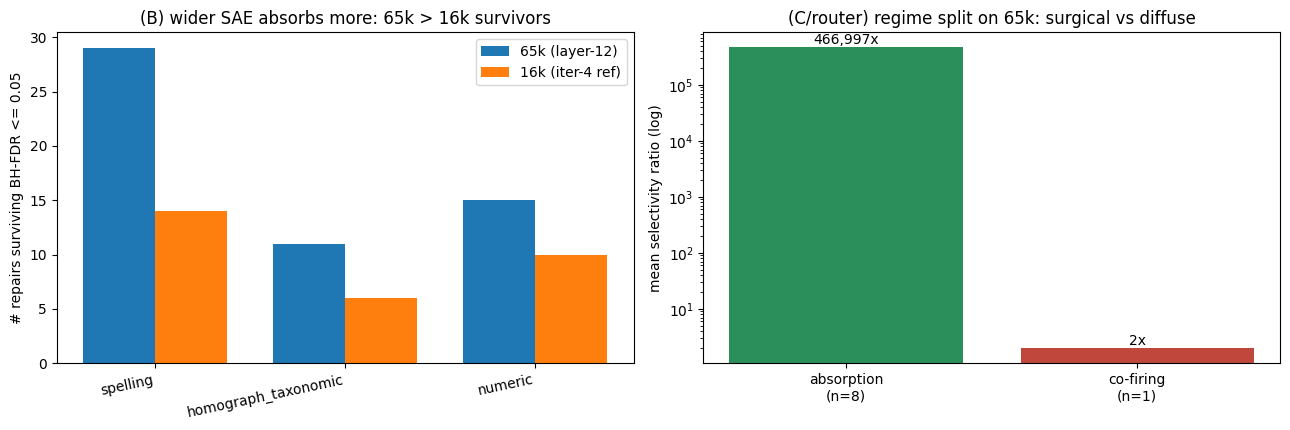


regime split (65k): {'absorption_mean_selectivity': 466996.718, 'absorption_mean_firing_jaccard': 0.007, 'co_firing_mean_selectivity': 1.986, 'co_firing_mean_firing_jaccard': 0.837, 'n_absorption': 8, 'n_co_firing': 1}


In [14]:
# (1) per-piece verdict summary table
piece_order = ["homograph_holes", "repair_fdr", "surgical", "router"]
summ = []
for dn in DICTS_TO_PROCESS:
    t = replication_tables[dn]
    row = {"dictionary": dn, "layer": t["layer"], "width": t["width"]}
    row.update({p: t["per_piece_verdicts"][p] for p in piece_order})
    row["OVERALL"] = t["overall_verdict"]
    summ.append(row)
df = pd.DataFrame(summ)
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# (2) FDR survivors per family: 65k vs 16k
fams = ["spelling", "homograph_taxonomic", "numeric"]
x = np.arange(len(fams)); w = 0.38
m65 = multiplicity_by_dict["65k"]["per_family_survive_FDR"]
ax = axes[0]
ax.bar(x - w/2, [m65.get(f, 0) for f in fams], w, label="65k (layer-12)")
ax.bar(x + w/2, [REF_16K["per_family_survive_FDR"].get(f, 0) for f in fams], w, label="16k (iter-4 ref)")
ax.set_xticks(x); ax.set_xticklabels(fams, rotation=12, ha="right")
ax.set_ylabel("# repairs surviving BH-FDR <= 0.05")
ax.set_title("(B) wider SAE absorbs more: 65k > 16k survivors")
ax.legend()

# (3) regime split (65k): absorption vs co-firing mean selectivity (log scale)
rs = replication_tables["65k"]["regime_split"]
labels = [f"absorption\n(n={rs['n_absorption']})", f"co-firing\n(n={rs['n_co_firing']})"]
vals = [rs["absorption_mean_selectivity"] or 0.0, rs["co_firing_mean_selectivity"] or 0.0]
ax = axes[1]
ax.bar(labels, vals, color=["#2a8f5a", "#c0473b"])
ax.set_yscale("log"); ax.set_ylabel("mean selectivity ratio (log)")
ax.set_title("(C/router) regime split on 65k: surgical vs diffuse")
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:,.0f}x", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("demo_summary.png", dpi=110)
plt.show()
print("\nregime split (65k):", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in rs.items()})